# MRI k-space Data Augmentation Visualization

이 노트북에서는 `utils/data/augmentation.py`의 augmentation 함수들을 사용하여 k-space 데이터의 augmentation 결과를 시각적으로 확인할 수 있습니다.

---

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import h5py
import random

# For reproducibility
np.random.seed(42)
torch.manual_seed(42)

In [11]:
in_dir = "../Data/train/kspace/brain_acc4_1.h5"
kspace_f = h5py.File(in_dir)
kspace = kspace_f['kspace']
kspace = np.array(kspace)  # Convert to numpy array
print(f"kspace shape: {kspace.shape}")
print("kspace example:", kspace[0, 0, 0, 0])  # Example of a single k-space point

kspace = np.stack([kspace.real, kspace.imag], axis=-1)
print(f"kspace shape after stacking: {kspace.shape}")
kspace = torch.tensor(kspace, dtype=torch.float32)

in_dir = "../Data/train/image/brain_acc4_1.h5"
image_f = h5py.File(in_dir)
target = image_f['image_label']
target = np.array(target)  # Convert to numpy array
target = torch.tensor(target, dtype=torch.float32)
print(f"target shape: {target.shape}")

kspace shape: (16, 16, 768, 396)
kspace example: (-4.305737e-06+1.0849908e-07j)
kspace shape after stacking: (16, 16, 768, 396, 2)
target shape: torch.Size([16, 384, 384])


In [6]:
import numpy as np
import torch
import torch.nn.functional as F
from utils.model.fastmri import fft2c, ifft2c, rss, complex_abs
from utils.common.utils import center_crop
import matplotlib.pyplot as plt

# --- Complex-valued transforms ---
# img: (S, C, H, W, 2) complex coil images
def complex_flip(img, horizontal=True):
    if horizontal:
        return img.flip(-2)
    else:
        return img.flip(-3)

def complex_translate(img, tx=0, ty=0):
    # Integer translation
    return torch.roll(img, shifts=(ty, tx), dims=(-3, -2))

def complex_affine(img, angle_deg=0, scale=0, shear_deg=0):
    a   = np.deg2rad(angle_deg)
    sh  = np.deg2rad(shear_deg)

    # 1. 회전 + 스케일 (2x2)
    rot_scale = torch.tensor([
        [ np.cos(a), -np.sin(a)],
        [ np.sin(a),  np.cos(a)]
    ], dtype=torch.float) * scale

    # 2. shear (x축 방향 shear) → (2x2)
    shear_mat = torch.tensor([
        [1.0, np.tan(sh)],
        [0.0, 1.0]
    ], dtype=torch.float)

    # 3. 최종 affine (2x2)
    affine_2x2 = shear_mat @ rot_scale  # (2x2) * (2x2)

    # 4. 2x2 → 2x3로 확장 (translation 없음)
    theta = torch.cat([affine_2x2, torch.zeros(2,1)], dim=1).unsqueeze(0)  # (1, 2, 3)

    # ------------------------------
    S, C, H, W, _ = img.shape           # (S, C, H, W, 2)
    out = []
    for s in range(S):
        coil_out = []
        for c in range(C):
            real = img[s, c, :, :, 0].unsqueeze(0).unsqueeze(0)  # (1,1,H,W)
            imag = img[s, c, :, :, 1].unsqueeze(0).unsqueeze(0)

            grid = F.affine_grid(theta, real.shape, align_corners=False).to(real.device)
            real_t = F.grid_sample(real, grid, mode='bicubic', align_corners=False).squeeze()
            imag_t = F.grid_sample(imag, grid, mode='bicubic', align_corners=False).squeeze()

            coil_out.append(torch.stack([real_t, imag_t], dim=-1))
        out.append(torch.stack(coil_out, dim=0))
    return torch.stack(out, dim=0)

# Real-valued transforms
# img: (S, H, W) real-valued image tensor
def real_flip(img, horizontal=True):
    if horizontal:
        return img.flip(-1)
    else:
        return img.flip(-2)

def real_translate(img, tx=0, ty=0):
    # Integer translation
    return torch.roll(img, shifts=(ty, tx), dims=(-2, -1))

def real_affine(img, angle_deg=0, scale=1.0, shear_deg=0):
    a   = np.deg2rad(angle_deg)
    sh  = np.deg2rad(shear_deg)

    # 1. 회전 + 스케일 (2x2)
    rot_scale = torch.tensor([
        [np.cos(a), -np.sin(a)],
        [np.sin(a),  np.cos(a)]
    ], dtype=torch.float) * scale

    # 2. shear (x축 방향 shear) → (2x2)
    shear_mat = torch.tensor([
        [1.0, np.tan(sh)],
        [0.0, 1.0]
    ], dtype=torch.float)

    # 3. 최종 affine (2x2)
    affine_2x2 = shear_mat @ rot_scale  # (2x2) * (2x2)

    # 4. 2x2 → 2x3로 확장 (translation 없음)
    theta = torch.cat([affine_2x2, torch.zeros(2,1)], dim=1).unsqueeze(0)  # (1, 2, 3)

    # ------------------------------
    S, H, W = img.shape  # img: (S, H, W)
    out = []
    for s in range(S):
        # (N=1, C=1, H, W)
        x = img[s].unsqueeze(0).unsqueeze(0)  # (1,1,H,W)
        
        # grid 생성 (theta: [N,2,3], output size: x.shape)
        grid = F.affine_grid(theta, x.shape, align_corners=False).to(img.device)

        # sampling
        warped = F.grid_sample(x, grid, mode='bicubic', align_corners=False)
        out.append(warped.squeeze())  # (H,W)
    
    return torch.stack(out, dim=0)  # (S,H,W)


def augment_kspace(kspace, target, augment_config=None):
    """
    kspace: (S, C, H, W, 2) complex-valued multi-coil k-space tensor
    target: (S, 384, 384) image tensor
    augment_config: dict with keys for each transform and their parameters
    Returns: augmented k-space tensor (S, C, H, W, 2) and corresponding image domain target tensor (S, C, H, W, 2)
    """
    augment_config = augment_config or {}
    # 1. kspace -> image domain
    img = ifft2c(kspace) # (S, C, H, W, 2)

    # Center crop to 384x384 before augmentation
    S, C, H, W, _ = img.shape
    ## (S,C,2,H,W) → (B,H,W) 로 펼치기  (B = S*C*2)
    x = img.permute(0,1,4,2,3).contiguous().view(-1, H, W)  # (B,H,W)
    img = center_crop(x, 384, 384)  # (B, 384, 384)
    img = img.view(S, C, 2, 384, 384).permute(0, 1, 3, 4, 2).contiguous()  # (S, C, 384, 384, 2)

    # 2. Apply augmentations (no RSS)
    if augment_config.get('flip', False):
        img = complex_flip(img, horizontal=augment_config.get('flip_horizontal', True))
        target = real_flip(target, horizontal=augment_config.get('flip_horizontal', True))

    if augment_config.get('translate', False):
        max_pixels=augment_config.get('translate_max', 8)
        tx = np.random.randint(-max_pixels, max_pixels+1)
        ty = np.random.randint(-max_pixels, max_pixels+1)
        
        img = complex_translate(img, tx=tx, ty=ty)
        target = real_translate(target, tx=tx, ty=ty)

    if augment_config.get('affine', False):
        rot_range=augment_config.get('affine_rot', 0)
        scale_range=augment_config.get('affine_scale', 0)
        shear_range=augment_config.get('affine_shear', 0)

        angle_deg = np.random.uniform(-rot_range, rot_range)
        scale = np.random.uniform(1-scale_range, 1+scale_range)
        shear_deg = np.random.uniform(-shear_range, shear_range)

        img = complex_affine(img, angle_deg=angle_deg, scale=scale, shear_deg=shear_deg)
        target = real_affine(target, angle_deg=angle_deg, scale=scale, shear_deg=shear_deg)

    # 3. image domain -> kspace
    x = img.permute(0,1,4,2,3).contiguous().view(-1, 384, 384)  # (B, 384, 384)
    img = center_crop(x, H, W)  # (B, H, W)
    img = img.view(S, C, 2, H, W).permute(0, 1, 3, 4, 2).contiguous()  # (S, C, H, W, 2)
    kspace_aug = fft2c(img)

    return kspace_aug, target

def visualize_augmentation(kspace, target, augment_config=None):
    """
    kspace: (S, C, H, W, 2) complex-valued multi-coil k-space tensor
    augment_config: dict for augmentation
    coil_idx: which coil to plot (int or 'all')
    """
    # 1. 원본/augment된 image (배치별)
    img_orig = rss(complex_abs(ifft2c(kspace)), dim=1)  # (S, H, W)
    img_orig = center_crop(img_orig, 384, 384)
    kspace_aug, img_aug = augment_kspace(kspace, target, augment_config)

    S = img_orig.shape[0]
    # coil_idx는 C축 기준, S개 배치 모두 시각화
    plt.figure(figsize=(8, 4 * S))
    for s in range(1):
        plt.subplot(S, 2, 2*s+1)
        plt.imshow(img_orig[s].cpu(), cmap='gray')
        plt.title(f'Original Sample {s}')
        plt.axis('off')
        plt.subplot(S, 2, 2*s+2)
        plt.imshow(img_aug[s].cpu(), cmap='gray')
        plt.title(f'Augmented Sample {s}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

Augmentation config: {'flip': True, 'flip_horizontal': True, 'translate': True, 'translate_max': 0, 'affine': True, 'affine_rot': 0, 'affine_scale': 0, 'affine_shear': 0}


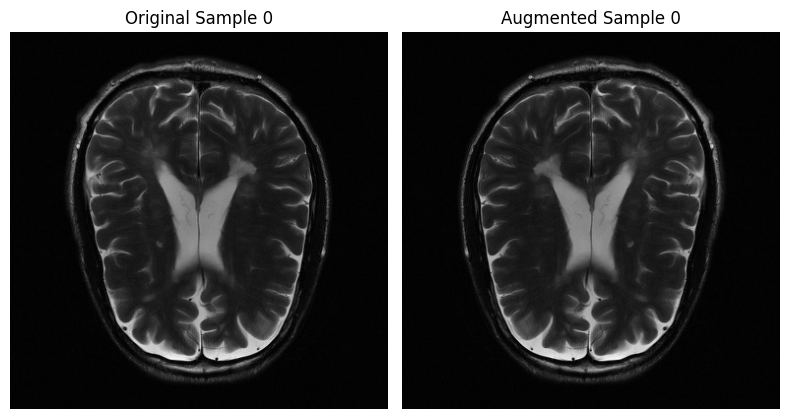

In [12]:
# Define augmentation configuration
augment_config = {
            # 'flip': random.choice([True, False]),
            'flip': True,
            'flip_horizontal': True,
            # 'translate': random.choice([True, False]),
            'translate': True,
            'translate_max': 0,
            'affine': True,
            'affine_rot': 0,
            'affine_scale': 0,
            'affine_shear': 0
        }
print("Augmentation config:", augment_config)

# Visualize original and augmented images
visualize_augmentation(kspace, target, augment_config)

KeyError: 0

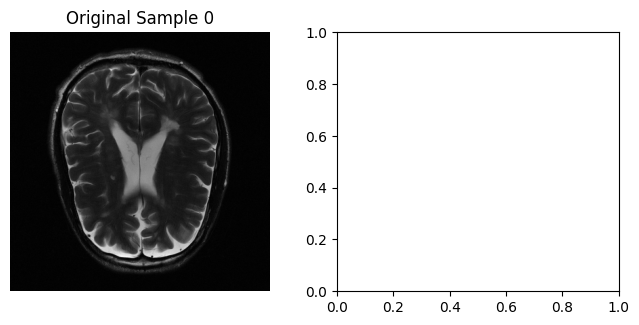

In [ ]:
# Visualize original and augmented images
visualize_augmentation(kspace, augment_config)

In [ ]:
# Try different augmentation settings
augment_config2 = {
    'flip': True,
    'flip_horizontal': False,
    'rotate90': False,
    'translate': True,
    'translate_max': 4,
    'affine': True,
    'affine_rot': 2,
    'affine_scale': 0.02,
    'affine_shear': 1
}
print("Different augmentation config:", augment_config2)
visualize_augmentation(kspace, augment_config2, coil_idx=0)